# 定理19　自由意思定理 — 数値で見る例

> **この notebook の位置づけ。** 数値シミュレーション（説明用のトイ例）で、証明ではありません。
> Lean で確かめた範囲は最後の「Lean との対応」に書きます。原文の主張・この例が見せること・仏教的な読み（解釈）は別の見出しに分けます。

## 1. 定理19は何を言っているのか

### 原文の主張

定理19は「**自由とは、ゴールを取り替えたとき、行動がどれだけ変わりうるか**」と読み、それを **容量** で測ります。

* $G$：選ぼうとする **ゴール**。
* $Y$：実際の **行動（出力）**。
* $X$：いまの **状況**（文脈）。
* **条件付き相互情報量** $I(G;Y\mid X)$：状況 $X$ を知った上で、ゴール $G$ の違いが行動 $Y$ の違いにどれだけ写っているか（**選べている度合い**）。$G$ を取り替えても $Y$ が変わらなければ $0$。

抽象度 $\alpha$ での **自由意思容量** は、とりうる問題 $d$ と方策 $\pi$ のすべてにわたる最大値です。

$$
\mathcal F_i(\alpha)\;=\;\sup_{(d,\pi)}\;I(G;Y\mid X).
$$

結論は3つです。

1. **単調性：** $\alpha\preceq\beta\ \Longrightarrow\ \mathcal F_i(\alpha)\le\mathcal F_i(\beta)$。抽象度を上げても容量は **減らない**（許容対を保つ単射埋め込みがある場合）。
2. **端点正規化：** 両端 $\mathcal F(0)$（物理層）と $\mathcal F(\top)$（空）を $0$ と $1$ に固定する $f_i(\alpha)=\dfrac{\mathcal F(\alpha)-\mathcal F(0)}{\mathcal F(\top)-\mathcal F(0)}$ は一意で、$f_i(\top)=1$。
3. **決定論との両立：** 可測な決定論的方策 $Y=\varphi(X,G)$ が（ほとんどすべての入力 $x$ で）$g\mapsto\varphi(x,g)$ **単射** なら $I(G;Y\mid X)=H(G\mid X)$。ランダム性は不要です。逆に、**ゴールと独立なランダム出力** の容量は $0$ です。

**証明の心。** 高い抽象度で使える方策の集合は、低い抽象度のものを含みます。含む集合の上限は小さくならない、これが単調性です。物理層では未来が初期条件で決まっていて $G$ が $Y$ に影響する余地がなく $I=0$。両端 $0$ と $1$ を固定する一次の正規化は一通りしかありません。

### 記号とコード変数の対応

| 原文の記号 | 意味 | このコードでは |
| --- | --- | --- |
| $G$ | ゴール。4値、一様分布 | `pG = [0.25]*4` |
| $H(G\mid X)=\log4$ | ゴールの不確かさ（$X$ に依らず一様） | `H_G` |
| $Y$ | 出力。層 $\alpha$ では $m_\alpha$ 個のアルファベット | `m_alpha = [1,2,3,4,4]` |
| 決定論的方策 $\varphi:G\to Y$ | ゴールから出力への写像 | `phi` |
| $I(G;Y)$ | 相互情報量（$X$ は対称なので条件付けても同じ） | `mutual_info` |
| $\mathcal F(\alpha)$ | 層 $\alpha$ の容量（全方策の最大） | `F` |
| $f(\alpha)$ | 端点正規化 | `f` |

## 2. なぜこれが「定理19の例」と言えるのか

* **層が上がるほど使える出力が増える。** 物理層は出力が1種類（$m=1$）、$\alpha_1$ は2種類、$\alpha_2$ は3種類、$\alpha_3$ と空 $\top$ は4種類。低い層の方策は、高い層の方策に **埋め込める**（使わない出力をただ使わなければよい）ので、単調性の前提（許容対を保つ単射埋め込み）が成り立ちます。
* **容量を実際に計算する。** 決定論的方策 $\varphi:\{0,1,2,3\}\to\{0,\dots,m-1\}$ を **全て試して**、最大の相互情報量を取ります。
* **反例（解像度）。** 出力 $Y\in\mathbb R$ が **集合として単射** でも、「どこまで細かく区別して観測するか」（可測構造＝解像度）が粗いと、観測できる法則では $I=0$ になります。これは「単射であること」と「観測可能な単射であること」が別物だ、という注意（Lean の反例モデル `Theorem19_Counterexample.lean` の精神）です。

## 3. 容量を全探索で計算する

In [1]:
# %% 準備
import itertools
import numpy as np
import matplotlib.pyplot as plt
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # フォント警告を抑制
try:
    import japanize_matplotlib  # Colab: !pip -q install japanize-matplotlib
except Exception:
    plt.rcParams["font.family"] = ["Noto Sans CJK JP", "IPAexGothic", "sans-serif"]

pG = np.full(4, 0.25)                          # G の事前(X に依らず一様)
H_G = -(pG * np.log(pG)).sum()                 # = log 4 = H(G|X)

def mutual_info(kernel):
    """kernel[g, y] = P(y|g)。I(G;Y) (X は対称なので条件付けても同じ) を返す。"""
    joint = pG[:, None] * kernel
    py = joint.sum(axis=0, keepdims=True)
    m = joint > 0
    return (joint[m] * np.log(joint[m] / (pG[:, None] * py)[m])).sum()

def capacity(m):
    """出力アルファベット m 個での決定論的方策 φ:G→{0..m-1} 全探索の最大 I。"""
    best = 0.0
    for phi in itertools.product(range(m), repeat=4):
        K = np.zeros((4, m)); K[np.arange(4), phi] = 1
        best = max(best, mutual_info(K))
    return best

layers = ["物理層0", "α1", "α2", "α3", "空⊤"]
m_alpha = [1, 2, 3, 4, 4]                      # 層ごとの出力アルファベット数(単調)
F = np.array([capacity(m) for m in m_alpha])
f = (F - F[0]) / (F[-1] - F[0])                # 端点正規化

$m=1$ では出力が1種類しかないので $I=0$。$m=2$ ではゴール4値を2つに分けるので最良は $2+2$ の分割で $\log2$。$m=3$ では $2+1+1$ の分割で $-\bigl(\tfrac12\log\tfrac12+2\cdot\tfrac14\log\tfrac14\bigr)=\tfrac32\log2\approx1.0397$。$m=4$ では全部区別できて $\log4$。

## 4. 反例：単射でも解像度が粗いと情報ゼロ

In [2]:
# %% 反例: 単射だが解像度が粗い出力
y_of_g = np.array([0.1, 0.4, 0.6, 0.9])        # 集合として単射 g ↦ y(R の中)
def observed_MI(bins):
    idx = np.minimum((y_of_g * bins).astype(int), bins - 1)   # σ代数 = bins 個の区間
    K = np.zeros((4, bins)); K[np.arange(4), idx] = 1
    return mutual_info(K)
bins = [1, 2, 3, 5, 10]
MI_bins = [observed_MI(b) for b in bins]
Y_indep = mutual_info(np.full((4, 4), 0.25))   # ゴール独立のランダム出力

4つのゴールに対する出力 $y(g)=0.1,\,0.4,\,0.6,\,0.9$ は **互いに異なる** ので集合として単射です。
ところが観測の σ 代数（解像度）を「区間 `bins` 個」にすると、同じ区間に入った出力は区別できません。`bins=1`（全体が1つの区間＝自明な σ 代数）では4つとも同じ区間に入ります。

## 5. 図を読む

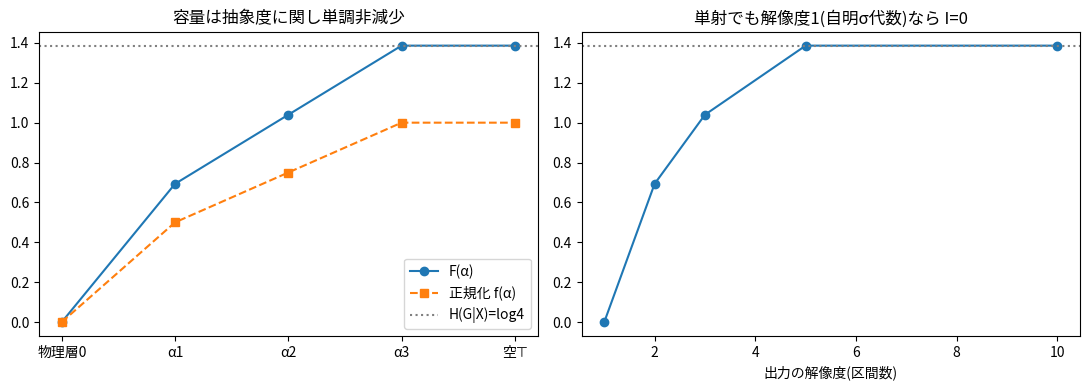

In [3]:
# %% 可視化
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(layers, F, "o-", label="F(α)"); ax[0].plot(layers, f, "s--", label="正規化 f(α)")
ax[0].axhline(H_G, ls=":", c="gray", label="H(G|X)=log4"); ax[0].legend(); ax[0].set_title("容量は抽象度に関し単調非減少")
ax[1].plot(bins, MI_bins, "o-"); ax[1].axhline(H_G, ls=":", c="gray"); ax[1].set_xlabel("出力の解像度(区間数)")
ax[1].set_title("単射でも解像度1(自明σ代数)なら I=0")
plt.tight_layout(); plt.show()

### 左：容量は抽象度について単調非減少

青い折れ線が容量 $\mathcal F(\alpha)$、橙の破線が端点正規化 $f(\alpha)$、灰色の点線が上限 $H(G\mid X)=\log4\approx1.386$。

* 物理層：$\mathcal F=0$（自由意思容量ゼロ）。
* $\alpha_1$：$\log2\approx0.693$（$f=0.5$）。
* $\alpha_2$：約 $1.040$（$f=0.75$）。
* $\alpha_3$：$\log4\approx1.386$（$f=1$）。灰色の点線に **ちょうど届きます**。
* 空 $\top$：$\alpha_3$ と同じ値。**減りません。**

左から右へ、**単調に増え（あるいは同じ）、決して下がりません**。これが単調性 $\alpha\preceq\beta\Rightarrow\mathcal F(\alpha)\le\mathcal F(\beta)$ です。
橙は両端が $0$ と $1$ に揃っています（$f(\text{物理層})=0$、$f(\top)=1$）。
また、決定論的な方策だけでも（ランダム性なしでも）容量は正になっています。**決定論と自由は、階層が違えば両立する** という原文の主張に対応します。

### 右：解像度と観測される相互情報量

横軸は出力の解像度（区間の数）。
* **解像度 1：$I=0$。** 4つの出力が集合として異なっていても、観測では何も区別できないので情報はゼロ。
* **解像度 2：$\log2$。** 出力が $\{0.1,0.4\}$ と $\{0.6,0.9\}$ の2つに分かれます。
* **解像度 3：約 $1.040$。** $\{0.1\},\{0.4,0.6\},\{0.9\}$ の分割（$1+2+1$）。
* **解像度 5 以上：$\log4$。** 4つとも別の区間に入るので全部区別でき、$I=H(G\mid X)$ に達します。5 と 10 は同じ値です。

したがって、「単射であること」だけでは足りず、**観測の解像度が十分** でなければ、自由は観測に現れません。

## 6. 数値確認

In [4]:
# %% 数値確認
print("F(α) =", np.round(F, 4), " f(α) =", np.round(f, 3), " 独立ランダム出力 I =", Y_indep)
assert (np.diff(F) >= -1e-12).all() and abs(F[0]) < 1e-12 and abs(F[-1] - H_G) < 1e-12
assert abs(f[0]) < 1e-12 and abs(f[-1] - 1) < 1e-12 and abs(Y_indep) < 1e-12
assert abs(MI_bins[0]) < 1e-12 and MI_bins[-1] > 1.3   # 解像度1: 0, 解像度10: ≈log4=1.386

F(α) = [0.     0.6931 1.0397 1.3863 1.3863]  f(α) = [0.   0.5  0.75 1.   1.  ]  独立ランダム出力 I = 0.0


出力：$F(\alpha)=[0,\,0.6931,\,1.0397,\,1.3863,\,1.3863]$、$f=[0,\,0.5,\,0.75,\,1,\,1]$、ゴール独立のランダム出力の $I=0.0$。
`assert` は、(i) $F$ が単調非減少で $F(\text{物理層})=0$、$F(\top)=\log4$、(ii) $f$ の両端が $0,1$、ゴール独立出力は $I=0$、(iii) 解像度 1 で $I=0$、解像度 10 で $I\approx\log4$、を確認します。

## 7. 仏教的な意義（解釈）

> 原文の説明にそった **思想的な読み** で、Lean で形式化された数理結論そのものではありません。

* **自由を気分ではなく容量で測る。** 原文は「物理の層では未来は初期条件で決まっていて容量 0。抽象度を上げるほど容量は決して減らず、はしごのてっぺん『空』で最大になる」と説明します。左の図の階段そのものです。
* **決定論と自由は階層が違えば両立する。** 物理層（容量 0）と高抽象度層（容量 $>0$）は矛盾しません。
* **「皆苦」と「自由」の関係（原文の整合性確認③）。** どうせ苦なら自由に意味は？——ある。容量は抽象度とともに増え、定理22により包摂更新では減らない。苦の合計を減らす方向へ登る自由こそが、定理24の「構造的な宿題」への答えだ、と原文は述べます。
* **空 $\top$ で最大（$f(\top)=1$）。** はしごのてっぺんが「空」である、という読みは定理22・26につながります。
* ここで測っているのは **選択の容量** であり、「何を選ぶべきか」の善悪は含みません。

## 8. Lean との対応

対応ファイル：`Tomabechi/Examples/Theorem19_FreeWillCapacity.lean`。

| | 内容 | 状態 |
| --- | --- | --- |
| 有限ゴール（4値）・決定論的方策の容量 | 単調性、$F(1)=0$（出力 1 種類）、$F(4)=\log4$、$I\le H$、**単射なら $I=H$**、端点正規化 | 証明済 |
| $F(2),F(3)$ の具体値 | $F(2)=\log2$、$F(3)=\tfrac32\log2$（出力が 2 個・3 個の方策を全部列挙して最大値を決め、$2+2$・$2+1+1$ の分割が達成） | 証明済 |
| ゴール独立なランダム出力 | 任意の有限確率出力分布で、一般の測度論的な条件付き相互情報量（KL ダイバージェンスで定義）が **厳密に 0**（二点分布 $(1/3,2/3)$ の具体例も） | 証明済 |
| 解像度の粗い観測の反例 | 解像度 $b=1,2,10$ の相互情報量（$0,\ \log2,\ \log4$） | 証明済 |
| 解像度 $b=3,5$ の値（上の図）、乱数列 | 数値のみ | 未証明 |

* このトイは **有限ゴール・決定論的方策**（と、独立なランダム出力）に限った特殊ケースで、一般の $\sup_{(d,\pi)}$ を計算しているわけではありません。確率的方策を含めた容量の最大値は計算していません。
* ランダム出力で証明したのは「ゴールと独立なら情報は 0」であって、一般の確率的カーネルの容量ではありません。